In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap
import seaborn as sns
from tqdm import tqdm

import constants as k
import paths as p
import utils
from calculate_instantaneous_firing_rate import calculate_firing_rates
from raster_plot import plot_raster

In [3]:
# Add a new sorter: BACKGROUND_WAIT_LENGTH = background_length + wait_length
k.BACKGROUND_WAIT_LENGTH = "background_wait_length"

In [4]:
# raster_dir = os.path.join(p.ONE_DRIVE_DIR, 'raster_plots')
raster_dir = os.path.join(p.FIGURES_DIR, 'raster_plots')
if not os.path.exists(raster_dir):
    os.makedirs(raster_dir)
    
units_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_vetted.csv'), index_col=0).sort_values('unit_id')

get data for one unit to debug

In [8]:
events, trials, spikes = utils.get_data_for_debugging(units_vetted)

In [9]:
# Ensure background_wait_length is present in trials for all downstream use
if 'background_wait_length' not in trials.columns:
    trials['background_wait_length'] = trials['background_length'] + trials['wait_length']

In [10]:
def prepare_data_for_raster(events, trials, spikes, sorter):
    # Handle custom sorter for background_wait_length
    if sorter == k.BACKGROUND_WAIT_LENGTH:
        if 'background_wait_length' not in trials.columns:
            trials = trials.copy()
            trials['background_wait_length'] = trials['background_length'] + trials['wait_length']
        sorted_trial_id = trials.sort_values(by='background_wait_length').trial_id.tolist()
    else:
        sorted_trial_id = trials.sort_values(by=sorter).trial_id.tolist()
    events_raster = events.groupby('trial_id')
    spikes_raster = spikes.groupby('trial_id')
    return events_raster, spikes_raster, sorted_trial_id

### raster plot

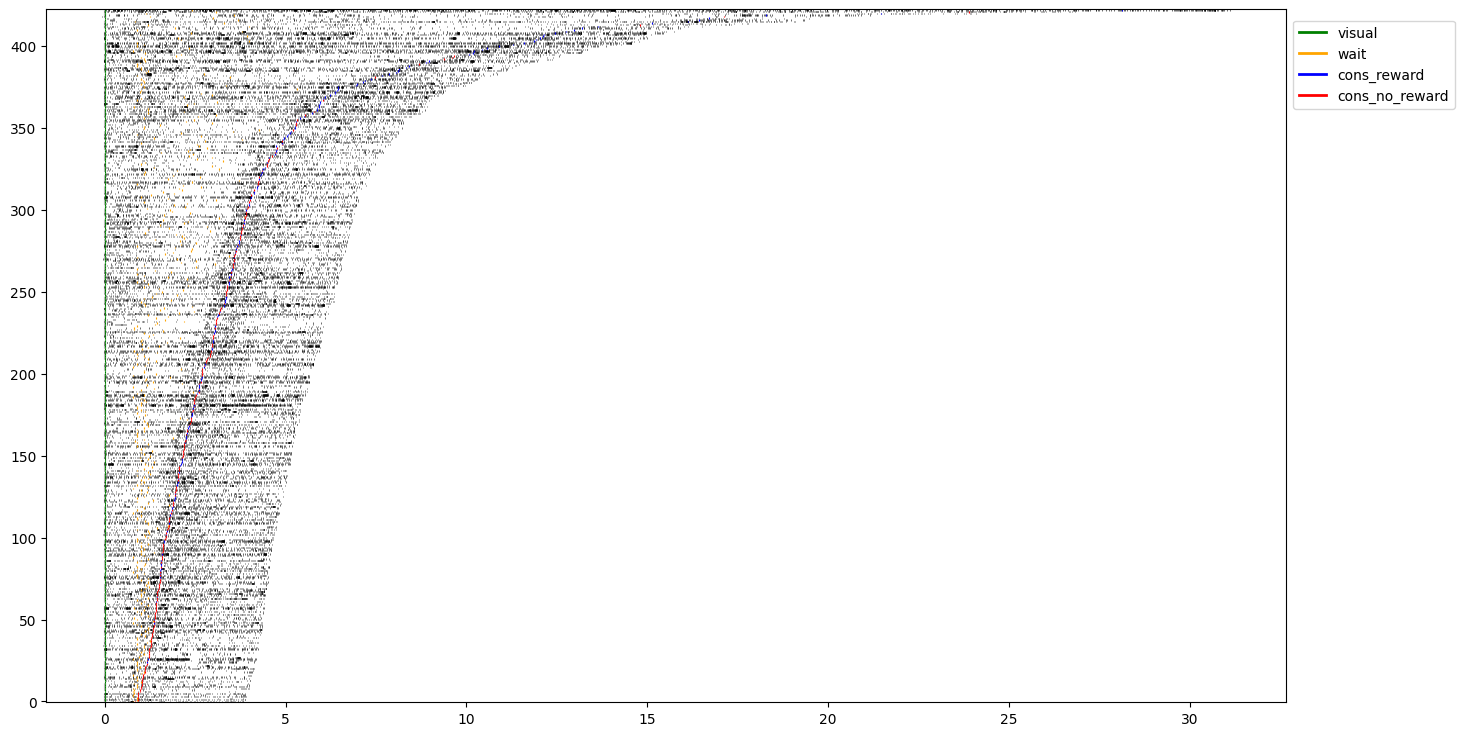

In [11]:
anchor = k.TO_CUE_ON
sorter = k.BACKGROUND_WAIT_LENGTH
_, ax = plt.subplots(figsize=(16,9))

plot_raster(ax, events, trials, spikes, anchor, sorter)

### histo plot

In [5]:
viridis_palette = ListedColormap(plt.cm.viridis(np.linspace(0, 1, 5)))  # generating 5 colors for 4 quantile + missed
colors = [viridis_palette(i) for i in range(5)]
quartile_colors = colors[:4]
missed_color = colors[4]

In [6]:
def prepare_data_for_histogram_by_quantile(trials, spikes, anchor, sorter):
    # Calculate the aligned start and end time based on the anchor
    if anchor == k.TO_CUE_ON:
        # boundaries: trial start (0) -> cue off time
        trials['aligned_start_time'] = 0 - trials["cue_on_time"]
        trials['aligned_end_time'] = trials['cue_off_time'] - trials["cue_on_time"]
    
    elif anchor == k.TO_CUE_OFF:
        # boundaries: cue on time -> consumption time (or trial_length if consumption is missing)
        trials['aligned_start_time'] = trials['cue_on_time'] - trials["cue_off_time"]
        # Handle missing decision_time
        mask = trials['decision_time'].isna()
        trials.loc[~mask, 'aligned_end_time'] = trials['decision_time'] - trials["cue_off_time"]
        trials.loc[mask, 'aligned_end_time'] = trials['trial_length'] - trials["cue_off_time"]
    
    elif anchor == k.TO_DECISION:
        # boundaries: cue off time -> trial end
        trials['aligned_start_time'] = trials["cue_off_time"] - trials["decision_time"]
        trials['aligned_end_time'] = trials['trial_length'] - trials["decision_time"]
    
    # Calculate quantiles only on non-missed trials
    non_missed_trials = trials[~trials['missed']].copy()
    non_missed_trials['quantile'] = pd.qcut(non_missed_trials[sorter], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    # missed trials will have NaN quantile
    trials = trials.merge(non_missed_trials[['trial_id', 'quantile']], on='trial_id', how='left')

    # get spikes from ancored periods
    relevant_periods = k.ANCHORED_PERIODS[anchor]
    spikes_histo = spikes.loc[spikes.period.isin(relevant_periods)].copy()
    
    # get trials with spikes
    trials_with_spikes = spikes_histo['trial_id'].unique()
    trials_histo = trials[trials['trial_id'].isin(trials_with_spikes)].copy().sort_values('quantile')
    
    return trials_histo, spikes_histo

In [7]:
def plot_firing_rates_by_quantile(ax, 
                                  trials, spikes, 
                                  anchor, sorter, 
                                  time_step, sigma, trial_count_mask, 
                                  show_legend=True):
    """Plots firing rates on given axes with legend on the right."""
    trials_histo, spikes_histo = prepare_data_for_histogram_by_quantile(trials, spikes, anchor, sorter)
    ax.axvline(0, color='tab:gray', linestyle='--', alpha=0.5, label=anchor)
    
    # Calculate and plot rates for all trials
    bin_centers, mean_fr, sem_fr = calculate_firing_rates(
        trials_histo, spikes_histo, anchor, time_step, trial_count_mask, sigma
    )
    if len(bin_centers) > 0:
        ax.plot(bin_centers, mean_fr, 'gray', lw=1, alpha=0.6, label='All trials')
        ax.fill_between(bin_centers, mean_fr-sem_fr, mean_fr+sem_fr, color='gray', alpha=0.1)
    
    # Calculate and plot rates for each wait time quantile
    for i, quantile in enumerate(trials_histo['quantile'].unique()):
        trials_quantile = trials_histo.loc[trials_histo['quantile'] == quantile]
        spikes_quantile = spikes_histo.loc[spikes_histo.trial_id.isin(trials_quantile.trial_id)]
        bin_centers_q, mean_fr_q, sem_fr_q = calculate_firing_rates(
            trials_quantile, spikes_quantile, anchor, time_step, trial_count_mask, sigma
            )
        if len(bin_centers_q) > 0:
            ax.plot(bin_centers_q, mean_fr_q, color=quartile_colors[i], lw=1, label=quantile)
            ax.fill_between(bin_centers_q, mean_fr_q-sem_fr_q, mean_fr_q+sem_fr_q, 
                            color=quartile_colors[i], alpha=0.1)
    
    # Calculate and plot rates for missed trials
    if anchor != k.TO_DECISION:
        trials_missed = trials_histo.loc[trials_histo.missed == True]
        spikes_missed = spikes_histo.loc[spikes_histo.trial_id.isin(trials_missed.trial_id)]
        bin_centers_m, mean_fr_m, sem_fr_m = calculate_firing_rates(
            trials_missed, spikes_missed, anchor, time_step, trial_count_mask, sigma
        )
        if len(bin_centers_m) > 0:
            ax.plot(bin_centers_m, mean_fr_m, color=missed_color, linestyle='-', lw=1, label='Missed')
            ax.fill_between(bin_centers_m, mean_fr_m-sem_fr_m, mean_fr_m+sem_fr_m, color=missed_color, alpha=0.1)

    if show_legend:
        ax.legend(bbox_to_anchor=(1, 1.05), loc='upper left')

In [ ]:
anchor = k.TO_DECISION
sorter = k.WAIT_LENGTH

time_step = 0.1
sigma = 1
trial_count_mask = 5

_, ax = plt.subplots(figsize=(16, 3))
plot_firing_rates_by_quantile(ax, trials, spikes, anchor, sorter,
                              time_step, sigma, trial_count_mask)

### combined

In [ ]:
def plot_raster_histo(unit_id, events, trials, spikes,
                      anchor, sorter,
                      time_step, sigma, trial_count_mask, 
                      full_trial=False):
    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex='col', gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(right=0.85)
    ax_raster = axes[0]
    ax_rate = axes[1]

    plot_raster(ax_raster, events, trials, spikes, anchor, sorter)
    plot_firing_rates_by_quantile(ax_rate, trials, spikes, anchor, sorter,
                                 time_step, sigma, trial_count_mask)

    ax_raster.set_ylabel("Trial")
    ax_rate.set_ylabel("Firing Rate (Hz)")
    ax_rate.set_xlabel("Time (s)")

    plt.suptitle(f"{unit_id} aligned {anchor} sorted by {sorter}")

    # Set xlim if not full_trial
    if not full_trial:
        if anchor == k.TO_CUE_ON:
            ax_raster.set_xlim(-0.2, 10)
            ax_rate.set_xlim(-0.2, 10)
        elif anchor == k.TO_CUE_OFF:
            ax_raster.set_xlim(-8, 6)
            ax_rate.set_xlim(-8, 6)
        elif anchor == k.TO_DECISION:
            ax_raster.set_xlim(-10, 3)
            ax_rate.set_xlim(-10, 3)

    plt.tight_layout()
    return fig

In [ ]:
anchor = k.TO_CUE_ON
sorter = k.TRIAL_NUM
full_trial = True
fig = plot_raster_histo("test", events, trials, spikes,
                        anchor, sorter,
                        time_step, sigma, trial_count_mask,
                        full_trial)

# Plot raster histo per quantile for each anchor sorter pair

loop through each anchor and sorter combo

In [ ]:
# runs when running master loop, no plots will be shown
import matplotlib
matplotlib.use('Agg')  # Headless mode (no GUI)

time_step = 0.1
sigma = 2 # smoothing over 2 bins. 2*0.1 = 0.2 seconds
trial_count_mask = 5
save_fig = True
regenerate = True

anchor_sorter_pairs = [
    (k.TO_CUE_ON, k.TRIAL_NUM),
    (k.TO_CUE_ON, k.BACKGROUND_LENGTH),
    (k.TO_CUE_ON, k.WAIT_LENGTH),
    (k.TO_CUE_OFF, k.WAIT_LENGTH),
    (k.TO_DECISION, k.WAIT_LENGTH)
]

In [ ]:
# for debugging
# units_short= units_vetted.head(2)
# units_grouped = units_vetted.groupby("session_id")

In [ ]:
failed_units = []
units_grouped = units_vetted.groupby("session_id")
total_units = len(units_vetted) * len(anchor_sorter_pairs)  # Total across all anchors

with tqdm(total=total_units, desc="Processing all units") as pbar:
    for anchor, sorter in anchor_sorter_pairs:
        pbar.set_postfix_str(f"Anchor: {anchor}, Sorter: {sorter}")  # Show current anchor/sorter
        if sorter == k.TRIAL_NUM:
            full_trial = True
        else:
            full_trial = False

        for session_id, session_units in units_grouped:
            events, trials, units = utils.get_session_data(session_id)
            region = session_units['region'].iloc[0]
            figure_folder = os.path.join(raster_dir, f"raster_histo_{anchor}_by_{sorter}", region)
            os.makedirs(figure_folder, exist_ok=True)
            
            for _, unit_info in session_units.iterrows():
                unit_id = unit_info['unit_id']
                spikes = units[unit_info['id']]
                fig_path = os.path.join(figure_folder, f"{unit_id}.png")
                if os.path.exists(fig_path) and not regenerate:
                    pbar.update(1)
                    continue
                
                try:
                    fig = plot_raster_histo(
                        unit_id, events, trials, spikes, 
                        anchor, sorter,
                        time_step, sigma, trial_count_mask,
                        full_trial=full_trial
                    )
                    fig.savefig(fig_path, bbox_inches='tight', dpi=300, format='png')
                    fig.clf()
                    plt.close(fig)
                except Exception as e:
                    failed_units.append({'unit_id': unit_id, 'error': str(e)})
                finally:
                    plt.close('all')
                    pbar.update(1)

# Print summary
if failed_units:
    print("\nFailed units:")
    display(pd.DataFrame(failed_units))
    print(f"\nTotal failed: {len(failed_units)}/{total_units}")
else:
    print("All units processed successfully!")

# Poster example units for poster
raster, histo, regression for decision units

In [8]:
def parse_array(arr):
    if isinstance(arr, str):
        arr = arr.replace('\n', ' ')
        arr = np.fromstring(arr.strip('[]'), sep=' ')
    return arr

def plot_unit_summary(units_vetted, session_id, unit_num, anchor, sorter, time_step, sigma, trial_count_mask, significant_decision_units):
    unit_id = f"{session_id}_unit-{unit_num}"
    events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id=session_id, unit_id=unit_num)

    # First two subplots share x-axis, third is independent
    fig = plt.figure(figsize=(6, 14))
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 2, 2])

    ax_raster = fig.add_subplot(gs[0])
    ax_rate = fig.add_subplot(gs[1], sharex=ax_raster)
    ax_reg = fig.add_subplot(gs[2])

    # Raster plot
    plot_raster(ax_raster, events, trials, spikes, anchor, sorter, show_legend=False)
    ax_raster.set_xlim([-4, 2])
    ax_raster.set_ylabel("Trial")

    # Firing rates by quantile
    plot_firing_rates_by_quantile(ax_rate, trials, spikes, anchor, sorter,
                                  time_step, sigma, trial_count_mask, show_legend=False)
    ax_rate.set_xlim([-4, 2])
    ax_rate.set_ylabel("Firing Rate (Hz)")
    ax_rate.set_xlabel("Time (s)")

    # Regression plot (independent axis)
    quantile_dict = significant_decision_units.loc[significant_decision_units["unit_id"]==unit_id].iloc[0]
    x = parse_array(quantile_dict['x'])
    y = parse_array(quantile_dict['y'])
    sns.regplot(x=x, y=y, ax=ax_reg)
    stats_text = (
        f"y = {quantile_dict['slope']:.3f}x + {quantile_dict['intercept']:.3f}\n"
        f"R² = {quantile_dict['r_squared']:.3f}\n"
        f"p-value = {quantile_dict['p_value']:.4f}\n"
    )
    ax_reg.text(0.02, 0.98, stats_text,
                transform=ax_reg.transAxes,
                verticalalignment='top',
                horizontalalignment='left',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round'),
                fontsize=10,
                family='monospace')
    ax_reg.set_xlabel("Mean Wait Length (s)")
    ax_reg.set_ylabel("Peak Firing Rate")

    plt.tight_layout()
    plt.savefig(os.path.join(p.FIGURES_DIR, f"unit_summary_{unit_id}.png"), dpi=300)
    plt.close(fig)

In [11]:
significant_decision_units = pd.read_csv(os.path.join(p.DATA_DIR, 'significant_decision_units.csv'), index_col=0).sort_values('p_value')

In [12]:
significant_decision_units

,unit_id,region,x,y,slope,intercept,r_squared,p_value,n_quantiles,significant
494,RZ063_2025-03-06_str_unit-207,str,[2.26658488 0.37238216 3.62182948 1.1416865 2...,[38.7168333 19.38762529 43.64010847 29.617569...,6.686830,20.280141,0.971186,1.906834e-07,10,True
465,RZ063_2025-03-05_str_unit-116,str,[3.25550708 1.28492651 0.20196746 0.60441431 0...,[15.34315486 13.25102848 10.21431561 10.954074...,1.243361,10.970048,0.932823,5.724750e-06,10,True
160,RZ055_2024-10-31_str_unit-32,str,[ 9.06434902 3.28302166 12.06900078 0.400986...,[ 6.32482925 9.462679 4.53498647 11.110162...,-0.390932,10.256758,0.913505,1.586481e-05,10,True
62,RZ037_2024-07-16_str_unit-9,str,[ 2.36783951 4.36596099 1.31517584 0.542603...,[48.66568625 45.07601826 50.53314862 51.979545...,-1.282969,50.906876,0.908636,1.979173e-05,10,True
307,RZ059_2025-03-21_str_unit-165,str,[ 8.32971703 2.80945603 3.88528114 1.424407...,[17.36264015 12.01361798 14.94212682 12.397265...,0.549924,11.308135,0.908604,1.981990e-05,10,True
...,...,...,...,...,...,...,...,...,...,...
284,RZ059_2025-03-20_str_unit-155,str,[ 3.19814808 2.57119531 1.52177304 4.463758...,[2.5057942 2.23739517 3.19711051 1.49909725 2...,-0.088180,2.475319,0.417053,4.369473e-02,10,True
210,RZ058_2025-03-12_str_unit-176,str,[2.30741838 0.42287703 1.33402872 8.20440572 1...,[25.46518185 23.67109179 25.00793447 21.787506...,-0.322575,24.941612,0.416829,4.377000e-02,10,True
1,RZ034_2024-07-13_str_unit-109,str,[1.34252128 1.85329171 0.63520971 2.63913416 3...,[13.60768571 14.97597168 15.15430209 14.826802...,0.592377,14.025614,0.412863,4.511923e-02,10,True
131,RZ050_2024-11-21_str_unit-210,str,[10.315097 1.5100415 5.09345302 3.781438...,[40.3170308 34.22800272 33.4570863 36.729037...,0.542071,34.294414,0.409124,4.642291e-02,10,True


In [13]:
anchor = k.TO_DECISION
sorter = k.WAIT_LENGTH
time_step = 0.1
sigma = 1
trial_count_mask = 5

In [15]:
# Example usage:
session_id = 'RZ063_2025-03-06_str'
unit_num = 207

plot_unit_summary(units_vetted, session_id, unit_num, anchor, sorter, time_step, sigma, trial_count_mask, significant_decision_units)

In [17]:
# Plot unit summary for the top 30 units in significant_decision_units
top30 = significant_decision_units.head(30)
for _, row in top30.iterrows():
    session_id, unit_str = row['unit_id'].split('_unit-')
    unit_num = int(unit_str)
    plot_unit_summary(units_vetted, session_id, unit_num, anchor, sorter, time_step, sigma, trial_count_mask, significant_decision_units)

In [18]:
significant_decision_units

,unit_id,region,x,y,slope,intercept,r_squared,p_value,n_quantiles,significant
494,RZ063_2025-03-06_str_unit-207,str,[2.26658488 0.37238216 3.62182948 1.1416865 2...,[38.7168333 19.38762529 43.64010847 29.617569...,6.686830,20.280141,0.971186,1.906834e-07,10,True
465,RZ063_2025-03-05_str_unit-116,str,[3.25550708 1.28492651 0.20196746 0.60441431 0...,[15.34315486 13.25102848 10.21431561 10.954074...,1.243361,10.970048,0.932823,5.724750e-06,10,True
160,RZ055_2024-10-31_str_unit-32,str,[ 9.06434902 3.28302166 12.06900078 0.400986...,[ 6.32482925 9.462679 4.53498647 11.110162...,-0.390932,10.256758,0.913505,1.586481e-05,10,True
62,RZ037_2024-07-16_str_unit-9,str,[ 2.36783951 4.36596099 1.31517584 0.542603...,[48.66568625 45.07601826 50.53314862 51.979545...,-1.282969,50.906876,0.908636,1.979173e-05,10,True
307,RZ059_2025-03-21_str_unit-165,str,[ 8.32971703 2.80945603 3.88528114 1.424407...,[17.36264015 12.01361798 14.94212682 12.397265...,0.549924,11.308135,0.908604,1.981990e-05,10,True
...,...,...,...,...,...,...,...,...,...,...
284,RZ059_2025-03-20_str_unit-155,str,[ 3.19814808 2.57119531 1.52177304 4.463758...,[2.5057942 2.23739517 3.19711051 1.49909725 2...,-0.088180,2.475319,0.417053,4.369473e-02,10,True
210,RZ058_2025-03-12_str_unit-176,str,[2.30741838 0.42287703 1.33402872 8.20440572 1...,[25.46518185 23.67109179 25.00793447 21.787506...,-0.322575,24.941612,0.416829,4.377000e-02,10,True
1,RZ034_2024-07-13_str_unit-109,str,[1.34252128 1.85329171 0.63520971 2.63913416 3...,[13.60768571 14.97597168 15.15430209 14.826802...,0.592377,14.025614,0.412863,4.511923e-02,10,True
131,RZ050_2024-11-21_str_unit-210,str,[10.315097 1.5100415 5.09345302 3.781438...,[40.3170308 34.22800272 33.4570863 36.729037...,0.542071,34.294414,0.409124,4.642291e-02,10,True


In [25]:
units_qc_all = pd.read_csv(p.LOGS_DIR / "qc_per_unit_with_pass_flags.csv")
units_qc = units_qc_all[units_qc_all['qc_pass_all'] == True]

In [26]:
units_qc = units_qc.copy()
units_qc.loc[:, 'decision_units'] = units_qc['unit_id'].isin(significant_decision_units['unit_id'])

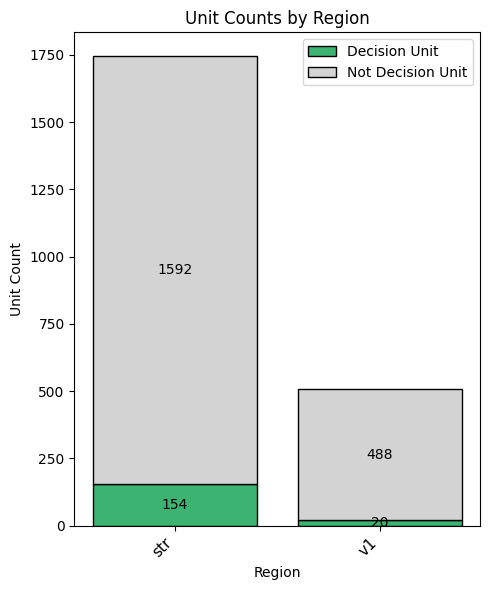

In [27]:
# Bar plot: total units and interval_keeper units per region
from paths import FIGURES_DIR


region_counts = units_qc.groupby(['region', 'decision_units']).size().unstack(fill_value=0)
x = range(len(region_counts))
fig, ax = plt.subplots(figsize=(5, 6))
bars_keeper = ax.bar(x, region_counts[True], label='Decision Unit', color='mediumseagreen', edgecolor='black')
bars_nonkeeper = ax.bar(x, region_counts[False], bottom=region_counts[True], label='Not Decision Unit', color='lightgray', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(region_counts.index, rotation=45, ha='right', fontsize=11)
ax.set_title('Unit Counts by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Unit Count')
# Value labels
for bar in bars_keeper + bars_nonkeeper:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{int(height)}',
                ha='center', va='center', color='black')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'decision_unit_counts_by_region.png', dpi=300)